0.8913913913913913
              precision    recall  f1-score   support

       blues       0.84      0.91      0.88       208
   classical       0.96      0.93      0.94       203
     country       0.83      0.86      0.84       186
       disco       0.87      0.87      0.87       199
      hiphop       0.91      0.88      0.89       218
        jazz       0.87      0.91      0.89       192
       metal       0.95      0.93      0.94       204
         pop       0.89      0.94      0.92       180
      reggae       0.89      0.88      0.88       211
        rock       0.91      0.81      0.86       197

    accuracy                           0.89      1998
   macro avg       0.89      0.89      0.89      1998
weighted avg       0.89      0.89      0.89      1998



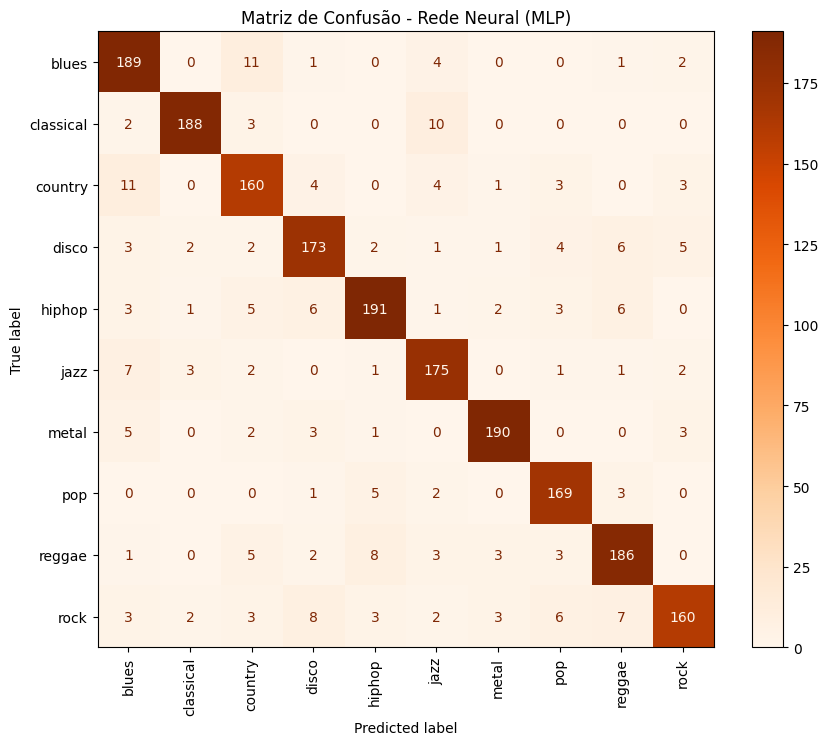

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv(r"C:\Users\hugos\Downloads\archive\Data\features_3_sec.csv")

X = df.drop(columns=['filename', 'length', 'label'])
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp_otimizada = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='tanh',
    alpha=0.01,
    max_iter=500,
    random_state=42
)

mlp_otimizada.fit(X_train, y_train)
y_pred_mlp = mlp_otimizada.predict(X_test)

print(accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
fig, ax = plt.subplots(figsize=(10, 8))
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=le.classes_)
disp_mlp.plot(cmap='Oranges', ax=ax, xticks_rotation='vertical')
plt.title("Matriz de Confusão - Rede Neural (MLP)")
plt.show()